In [1]:
import numpy as np
import os
from astropy.io import fits 

base_path="../data/2018_08_25" 
freq_2=os.path.join(base_path,"egress_pwr_02.5-03.5mHz_z0000km.fits")
freq_3=os.path.join(base_path,"egress_pwr_03.5-04.5mHz_z0000km.fits")
freq_4=os.path.join(base_path,"egress_pwr_04.5-05.5mHz_z0000km.fits")
freq_5=os.path.join(base_path,"egress_pwr_05.0-07.0mHz_z0000km.fits")
freq_7=os.path.join(base_path,"egress_pwr_07.0-09.0mHz_z0000km.fits")
freq_9=os.path.join(base_path,"egress_pwr_09.0-11.0mHz_z0000km.fits")

with fits.open(freq_5) as hdul5:
    hdr5=hdul5[0].header
    egression_pwr_5=hdul5[0].data
print(hdr5)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1024                                                  NAXIS2  =                 1024                                                  DAXIS1  =         5.000000E-04                                                  DAXIS2  =         5.000000E-04                                                  X0      =                512.0                                                  Y0      =                512.0                                                  DSUN_OBS=      151247846538.50                                                  OBS_L0  =           104.800728                                                  OBS_B0  =             7.031806                                                  REF_L0  =               104.89          

 [astropy.io.fits.verify]


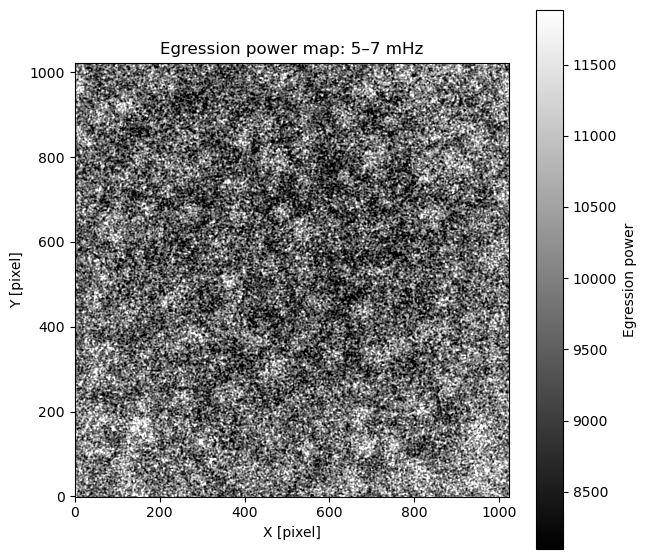

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.imshow(
    egression_pwr_5,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(egression_pwr_5,5),
    vmax=np.percentile(egression_pwr_5,98)
)

plt.colorbar(label="Egression power")
plt.title("Egression power map: 5–7 mHz")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")

plt.show()

2.5-3.5 mHz: shape = (1024, 1024), mean = 265609.5000
3.5-4.5 mHz: shape = (1024, 1024), mean = 190824.2031
4.5-5.5 mHz: shape = (1024, 1024), mean = 34519.3672
5.0-7.0 mHz: shape = (1024, 1024), mean = 9663.4414
7.0-9.0 mHz: shape = (1024, 1024), mean = 2134.5000
9.0-11.0 mHz: shape = (1024, 1024), mean = 771.9240


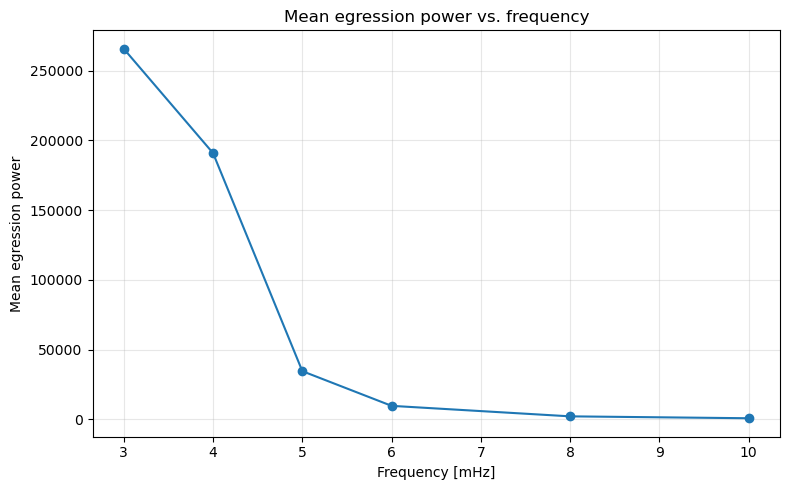

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# =====================================================
# Data paths
# =====================================================

base_path = "../data/2018_08_25"

files = {
    "2.5-3.5 mHz": "egress_pwr_02.5-03.5mHz_z0000km.fits",
    "3.5-4.5 mHz": "egress_pwr_03.5-04.5mHz_z0000km.fits",
    "4.5-5.5 mHz": "egress_pwr_04.5-05.5mHz_z0000km.fits",
    "5.0-7.0 mHz": "egress_pwr_05.0-07.0mHz_z0000km.fits",
    "7.0-9.0 mHz": "egress_pwr_07.0-09.0mHz_z0000km.fits",
    "9.0-11.0 mHz": "egress_pwr_09.0-11.0mHz_z0000km.fits",
}

# Central frequency of each frequency band [mHz]
frequencies = np.array([3, 4, 5, 6, 8, 10])

# =====================================================
# Calculate mean egression power
# =====================================================

mean_power = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data = hdul[0].data

    mean = np.nanmean(data)
    mean_power.append(mean)

    print(
        f"{freq_band}: "
        f"shape = {data.shape}, "
        f"mean = {mean:.4f}"
    )

# Convert list to NumPy array
mean_power = np.array(mean_power)

# =====================================================
# Plot frequency vs mean egression power
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    frequencies,
    mean_power,
    marker="o"
)

plt.xlabel("Frequency [mHz]")
plt.ylabel("Mean egression power")
plt.title("Mean egression power vs. frequency")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()